# EDA

In [27]:
import sys, pandas as pd
import chardet
from pathlib import Path


sys.path.append(str(Path.cwd().parent))

from config import DATA_RAW_DIR, ROOT
from utils.cleaning_utils import delete, normalize_all_text_columns, fill_rate
from utils.analysis_utils import plot_missing_bar, plot_numeric_histograms, plot_corr_heatmap, plot_qualitative


In [28]:
print(DATA_RAW_DIR)
print(DATA_RAW_DIR.resolve())
print(DATA_RAW_DIR.exists())

/home/coule/Documents/projets/incendies/data/data_raw
/home/coule/Documents/projets/incendies/data/data_raw
True


In [29]:
DATA_FILES = list(iter(DATA_RAW_DIR.glob("*.csv")))

In [30]:

f_1 = DATA_FILES[0]
f_1

PosixPath('/home/coule/Documents/projets/incendies/data/data_raw/Incendies1996.csv')

In [31]:
with open(Path(DATA_RAW_DIR / 'Incendies1971.csv'), 'rb') as file:
    encodage = chardet.detect(file.read(10000))

print(encodage)

{'encoding': 'utf-8', 'confidence': 0.812768, 'language': 'fr', 'mime_type': 'text/plain'}


In [32]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [33]:
def get_skiprows(file):
    with open(file, encoding="utf-8") as f:
        for i, line in enumerate(f):
            if line.startswith("Année"):
                return i
    return 0

In [34]:
dfs = [
    pd.read_csv(
        file,
        encoding=encodage["encoding"],
        sep=";",
        skiprows=get_skiprows(file)
    )
    for file in DATA_FILES
]

df = pd.concat(dfs, ignore_index=True)

In [35]:
df.shape

(142784, 24)

In [36]:
df.head()

,Année,Numéro,Département,Code INSEE,Nom de la commune,Date de première alerte,Surface parcourue (m2),Surface forêt (m2),Surface maquis garrigues (m2),Autres surfaces naturelles hors forêt (m2),Surfaces agricoles (m2),Autres surfaces (m2),Surface autres terres boisées (m2),Surfaces non boisées naturelles (m2),Surfaces non boisées artificialisées (m2),Surfaces non boisées (m2),Précision des surfaces,Type de peuplement,Nature,Décès ou bâtiments touchés,Nombre de décès,Nombre de bâtiments totalement détruits,Nombre de bâtiments partiellement détruits,Précision de la donnée
0,1996,83,06,06070,Gréolières,1996-01-03 15:04:00,17000,7990.0,8160.0,0.0,NaN,NaN,NaN,NaN,NaN,850.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,1996,439,11,11386,Talairan,1996-01-27 14:45:00,8000,0.0,8000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
2,1996,84,06,06023,Breil-sur-Roya,1996-01-31 17:26:00,2500,1175.0,1200.0,0.0,NaN,NaN,NaN,NaN,NaN,125.0,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN
3,1996,438,11,11198,Laure-Minervois,1996-02-10 15:46:00,10000,0.0,10000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,Involontaire (travaux),NaN,NaN,NaN,NaN,NaN
4,1996,901,2B,2B255,Quercitello,1996-02-13 21:27:00,200,94.0,96.0,0.0,NaN,NaN,NaN,NaN,NaN,10.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 142784 entries, 0 to 142783
Data columns (total 24 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   Année                                       142784 non-null  int64  
 1   Numéro                                      142784 non-null  int64  
 2   Département                                 142784 non-null  str    
 3   Code INSEE                                  142784 non-null  str    
 4   Nom de la commune                           142757 non-null  str    
 5   Date de première alerte                     142784 non-null  str    
 6   Surface parcourue (m2)                      142784 non-null  int64  
 7   Surface forêt (m2)                          138134 non-null  float64
 8   Surface maquis garrigues (m2)               118051 non-null  float64
 9   Autres surfaces naturelles hors forêt (m2)  107314 non-null  float64
 10  Surface

In [38]:
df.describe()

,Année,Numéro,Surface parcourue (m2),Surface forêt (m2),Surface maquis garrigues (m2),Autres surfaces naturelles hors forêt (m2),Surfaces agricoles (m2),Autres surfaces (m2),Surface autres terres boisées (m2),Surfaces non boisées naturelles (m2),Surfaces non boisées artificialisées (m2),Surfaces non boisées (m2),Type de peuplement,Nombre de décès,Nombre de bâtiments totalement détruits,Nombre de bâtiments partiellement détruits
count,142784.000000,142784.000000,1.427840e+05,1.381340e+05,1.180510e+05,1.073140e+05,6.588000e+03,6.572000e+03,1.702800e+04,1.069500e+04,1.042800e+04,1.094860e+05,78126.000000,1204.000000,1205.000000,1203.000000
mean,1998.427366,4293.443705,7.563299e+04,3.839479e+04,4.019227e+04,1.430720e+03,3.433630e+03,7.147463e+02,7.844942e+03,5.671529e+03,2.667294e+03,5.205811e+03,1.838440,0.004153,0.214938,0.128013
std,15.415429,4744.293085,1.101053e+06,6.901690e+05,5.330858e+05,3.531928e+04,5.781287e+04,2.807489e+04,8.084908e+04,1.174062e+05,3.996218e+04,7.873935e+04,1.466463,0.064335,3.668956,2.330491
min,1973.000000,1.000000,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,0.000000,0.000000,0.000000
25%,1985.000000,1060.000000,6.000000e+02,7.100000e+01,3.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,1.000000,0.000000,0.000000,0.000000
50%,1998.000000,2290.000000,2.000000e+03,5.000000e+02,9.600000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+01,1.000000,0.000000,0.000000,0.000000
75%,2012.000000,6628.000000,1.500000e+04,5.000000e+03,7.900000e+03,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+02,0.000000e+00,0.000000e+00,5.000000e+02,3.000000,0.000000,0.000000,0.000000
max,2025.000000,29813.000000,1.255200e+08,1.255200e+08,5.558400e+07,4.916000e+06,4.050000e+06,2.064500e+06,4.916000e+06,8.187317e+06,2.200000e+06,1.132000e+07,6.000000,1.000000,80.000000,74.000000


In [39]:
df.columns

Index(['Année', 'Numéro', 'Département', 'Code INSEE', 'Nom de la commune',
       'Date de première alerte', 'Surface parcourue (m2)',
       'Surface forêt (m2)', 'Surface maquis garrigues (m2)',
       'Autres surfaces naturelles hors forêt (m2)', 'Surfaces agricoles (m2)',
       'Autres surfaces (m2)', 'Surface autres terres boisées (m2)',
       'Surfaces non boisées naturelles (m2)',
       'Surfaces non boisées artificialisées (m2)',
       'Surfaces non boisées (m2)', 'Précision des surfaces',
       'Type de peuplement', 'Nature', 'Décès ou bâtiments touchés',
       'Nombre de décès', 'Nombre de bâtiments totalement détruits',
       'Nombre de bâtiments partiellement détruits', 'Précision de la donnée'],
      dtype='str')

## Supression des variables inutiles

In [40]:
df['Décès ou bâtiments touchés'].value_counts()

Décès ou bâtiments touchés
Non    7401
Oui      63
Name: count, dtype: int64

In [41]:
df['Nombre de décès'].value_counts()

Nombre de décès
0.0    1199
1.0       5
Name: count, dtype: int64

In [42]:
df['Nombre de bâtiments totalement détruits'].value_counts()

Nombre de bâtiments totalement détruits
0.0     1170
1.0       28
2.0        2
3.0        1
69.0       1
4.0        1
80.0       1
71.0       1
Name: count, dtype: int64

In [43]:
df['Nombre de bâtiments partiellement détruits'].value_counts()

Nombre de bâtiments partiellement détruits
0.0     1169
1.0       26
2.0        3
30.0       1
5.0        1
10.0       1
3.0        1
74.0       1
Name: count, dtype: int64

In [44]:
to_drop = [
    "Décès ou bâtiments touchés",
    "Nombre de décès",
    "Nombre de bâtiments totalement détruits",
    "Nombre de bâtiments partiellement détruits",
]

dropped_cols = []


# Attention : la fonction retourne un nouveau DataFrame, il faut le réaffecter.
for col in to_drop:
    df = delete(df, col, dropped_cols)


In [45]:
df.shape

(142784, 20)

In [46]:
df.columns

Index(['Année', 'Numéro', 'Département', 'Code INSEE', 'Nom de la commune',
       'Date de première alerte', 'Surface parcourue (m2)',
       'Surface forêt (m2)', 'Surface maquis garrigues (m2)',
       'Autres surfaces naturelles hors forêt (m2)', 'Surfaces agricoles (m2)',
       'Autres surfaces (m2)', 'Surface autres terres boisées (m2)',
       'Surfaces non boisées naturelles (m2)',
       'Surfaces non boisées artificialisées (m2)',
       'Surfaces non boisées (m2)', 'Précision des surfaces',
       'Type de peuplement', 'Nature', 'Précision de la donnée'],
      dtype='str')

## Etats des données avant traitement

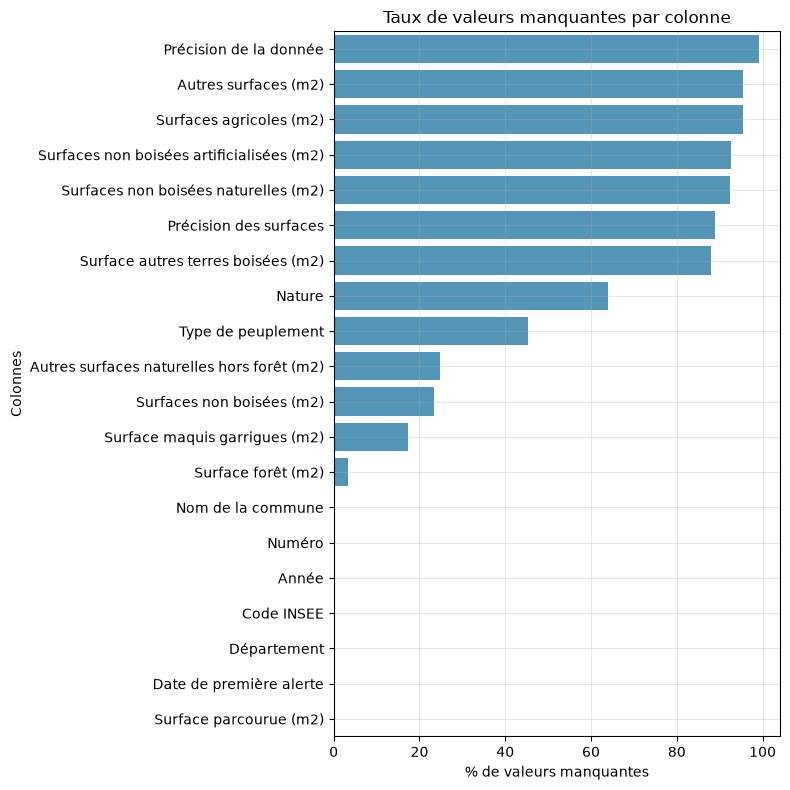

In [47]:
plot_missing_bar(df, figsize=(8,8))

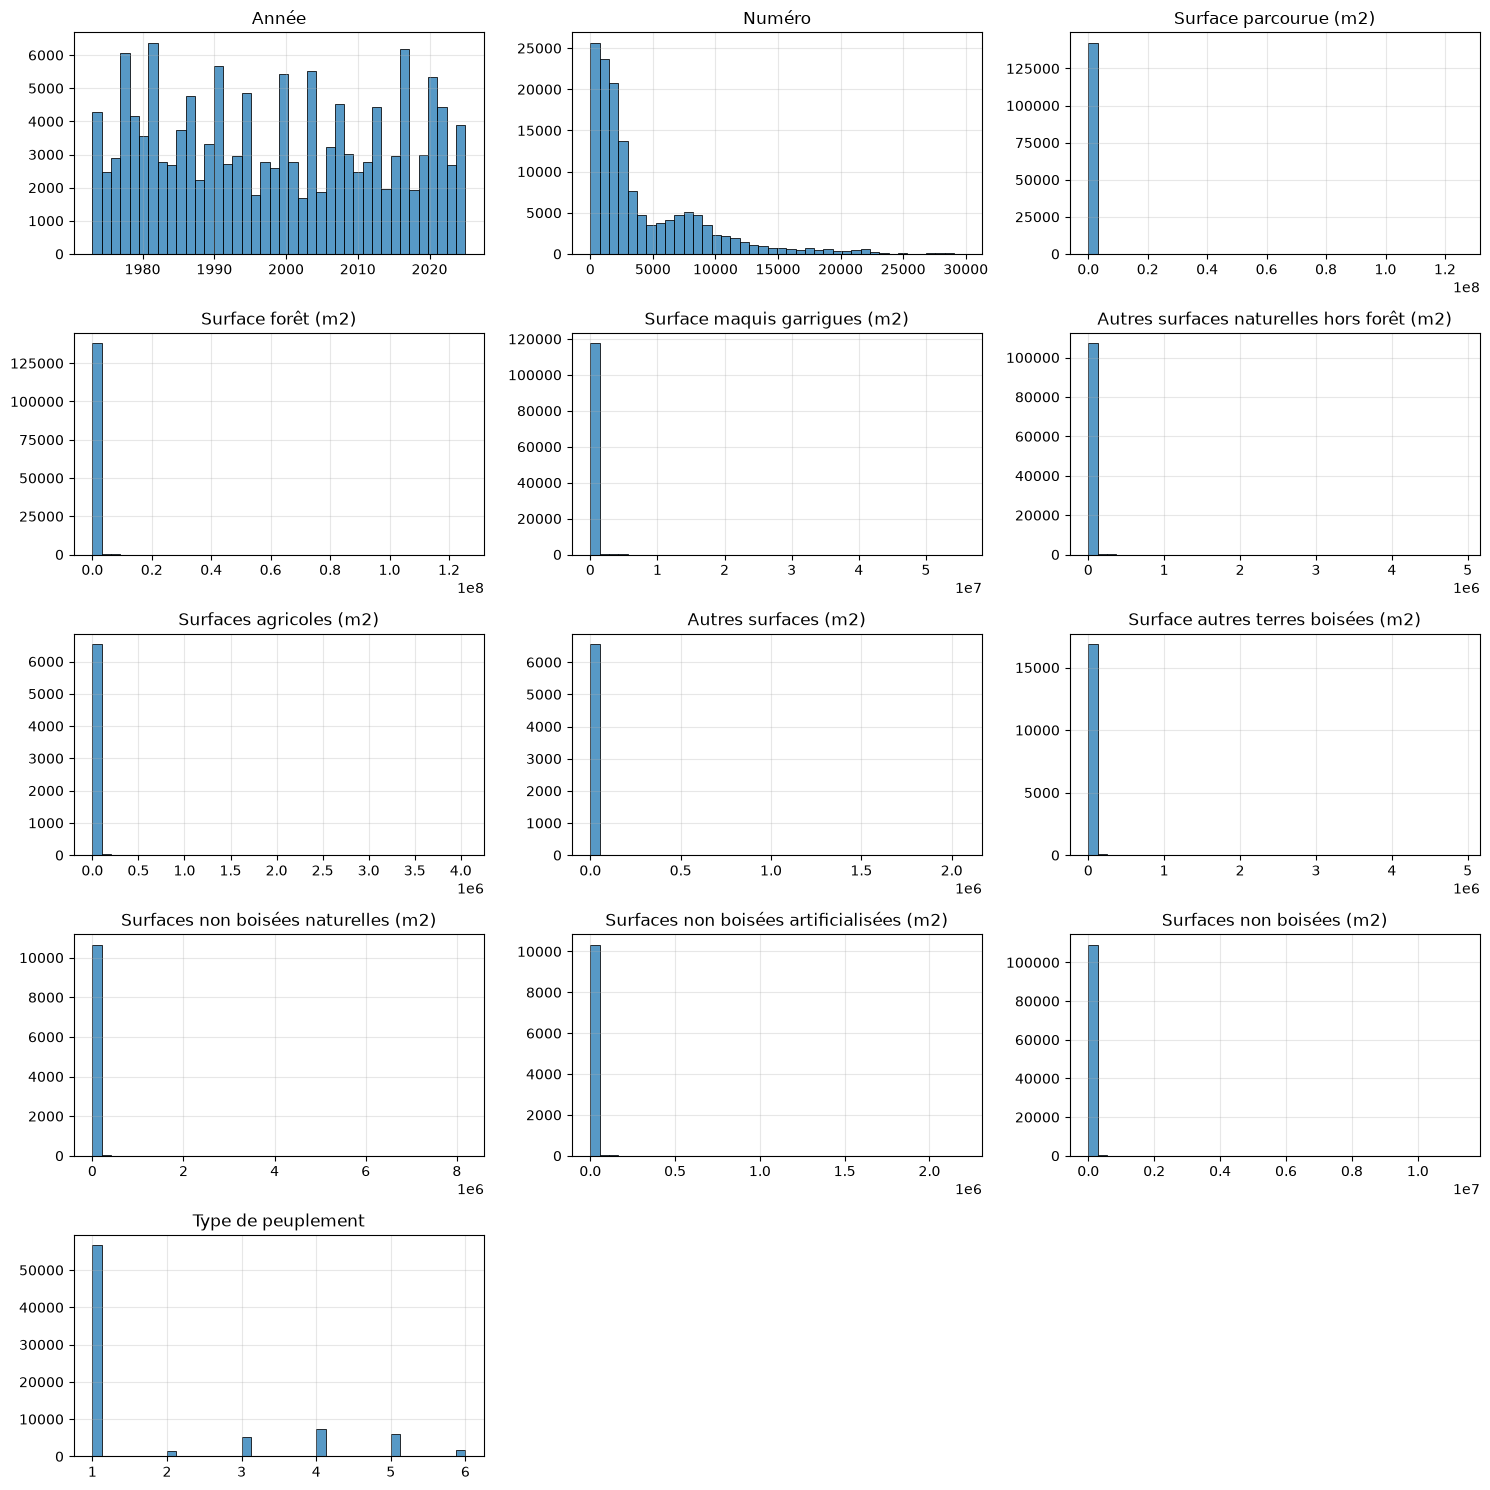

In [48]:
plot_numeric_histograms(df, bins=40, n_cols=3)

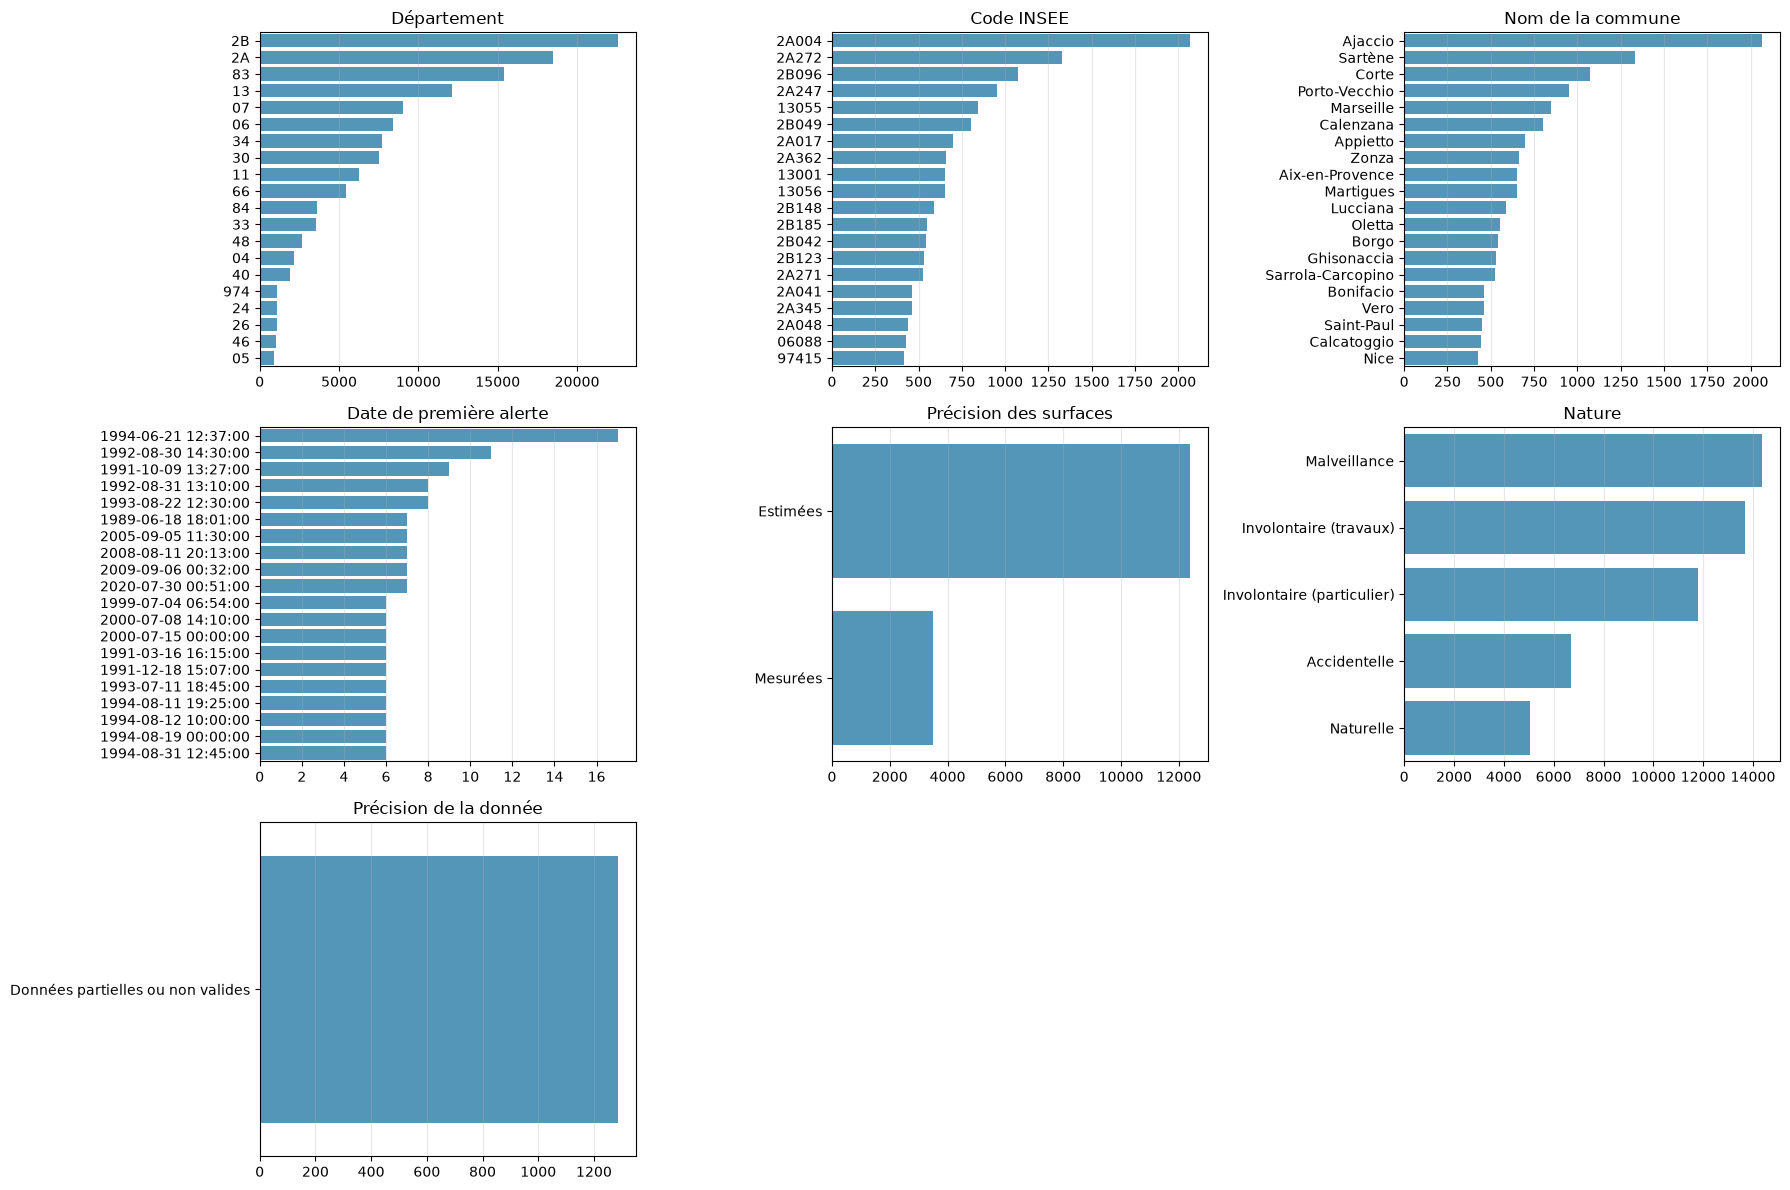

In [49]:
plot_qualitative(df, n_cols=3)

## Recherche de variable vide ou à une seule modalité

In [50]:
# Détection des variables qui n'ont qu'une seule modalité
# NaN étant considéré comme une modalité .....  (dropna=False)
unique_value_cols = df.columns[df.nunique(dropna=False)==1].tolist()
unique_value_cols

[]

In [ ]:
# Détection des variables vide
empty = df.columns[df.isna().all()].tolist()
empty

[]

In [70]:
df['Précision de la donnée'].value_counts()

Précision de la donnée
Données partielles ou non valides    1285
Name: count, dtype: int64

In [71]:
df['Autres surfaces (m2)'].value_counts()

Autres surfaces (m2)
0.0          6468
5000.0          4
600.0           4
2000.0          4
500.0           3
4.0             3
1000.0          3
10000.0         3
400.0           2
2.0             2
46.0            2
100.0           2
4800.0          2
250.0           2
3000.0          2
12000.0         2
1500.0          1
16960.0         1
3.0             1
130800.0        1
12500.0         1
16.0            1
12900.0         1
700.0           1
40.0            1
2600.0          1
430.0           1
2064500.0       1
14400.0         1
34400.0         1
30000.0         1
200.0           1
1700.0          1
18600.0         1
150.0           1
63500.0         1
300.0           1
7400.0          1
14200.0         1
20000.0         1
2500.0          1
52.0            1
42400.0         1
630000.0        1
48.0            1
2800.0          1
44700.0         1
160.0           1
11600.0         1
47100.0         1
45400.0         1
1440.0          1
235800.0        1
133200.0        1
29.0   

In [59]:
df['Surface forêt (m2)'].unique()

array([  7990.,      0.,   1175., ...,  10526.,  23020., 115800.],
      shape=(4113,))

In [73]:
df['Type de peuplement'].value_counts()

Type de peuplement
1.0    56638
4.0     7301
5.0     5884
3.0     5266
6.0     1624
2.0     1413
Name: count, dtype: int64

In [74]:
df['Type de peuplement'].value_counts()

Type de peuplement
1.0    56638
4.0     7301
5.0     5884
3.0     5266
6.0     1624
2.0     1413
Name: count, dtype: int64

In [75]:
df['Numéro'].value_counts()

Numéro
159      41
694      41
550      41
317      40
166      40
695      40
113      39
445      39
27       39
130      39
138      39
467      39
151      39
46       39
47       39
156      39
370      39
158      39
161      39
169      39
170      39
195      39
12       39
533      39
466      39
693      39
549      39
557      39
560      39
562      39
886      39
433      39
439      38
117      38
318      38
121      38
320      38
323      38
127      38
30       38
129      38
131      38
341      38
140      38
37       38
39       38
42       38
154      38
578      38
157      38
587      38
588      38
590      38
591      38
162      38
165      38
179      38
186      38
465      38
611      38
214      38
649      38
696      38
542      38
250      38
251      38
546      38
551      38
1028     38
554      38
561      38
1199     38
1200     38
395      38
430      38
293      38
99       37
100      37
101      37
102      37
103      37
106      37
109      

In [68]:
df['Numéro'].nunique()

19064

In [61]:
df.tail()

,Année,Numéro,Département,Code INSEE,Nom de la commune,Date de première alerte,Surface parcourue (m2),Surface forêt (m2),Surface maquis garrigues (m2),Autres surfaces naturelles hors forêt (m2),Surfaces agricoles (m2),Autres surfaces (m2),Surface autres terres boisées (m2),Surfaces non boisées naturelles (m2),Surfaces non boisées artificialisées (m2),Surfaces non boisées (m2),Précision des surfaces,Type de peuplement,Nature,Précision de la donnée
142779,2025,18606,2A,2A288,Sotta,2025-12-24 19:35:00,10,0.0,10.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,Estimées,NaN,Involontaire (particulier),NaN
142780,2025,14428,47,47228,Saint-Antoine-de-Ficalba,2025-12-27 16:46:46,3,3.0,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,Estimées,NaN,NaN,NaN
142781,2025,15855,33,33483,Saint-Sulpice-et-Cameyrac,2025-12-28 14:49:00,10,10.0,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,Estimées,NaN,NaN,NaN
142782,2025,13953,66,66054,Conat,2025-12-31 09:25:00,1,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,Estimées,NaN,Accidentelle,NaN
142783,2025,16811,11,11379,Sigean,2025-12-31 16:22:00,10,10.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,Mesurées,1.0,Involontaire (particulier),NaN


In [63]:
df.columns

Index(['Année', 'Numéro', 'Département', 'Code INSEE', 'Nom de la commune',
       'Date de première alerte', 'Surface parcourue (m2)',
       'Surface forêt (m2)', 'Surface maquis garrigues (m2)',
       'Autres surfaces naturelles hors forêt (m2)', 'Surfaces agricoles (m2)',
       'Autres surfaces (m2)', 'Surface autres terres boisées (m2)',
       'Surfaces non boisées naturelles (m2)',
       'Surfaces non boisées artificialisées (m2)',
       'Surfaces non boisées (m2)', 'Précision des surfaces',
       'Type de peuplement', 'Nature', 'Précision de la donnée'],
      dtype='str')